In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from textblob import TextBlob
from wordcloud import WordCloud

# Проверяем, какие файлы загружены в текущую папку Colab
print("Файлы в хранилище Colab:", os.listdir('.'))

Файлы в хранилище Colab: ['.config', 'customer_analytics_data.csv', 'Reviews.csv', 'sample_data']


In [3]:
import pandas as pd
import numpy as np

# 1. Загрузка датасета (из локального хранилища Colab)
file_name = 'customer_analytics_data.csv'
df = pd.read_csv(file_name)

print("--- ИСХОДНЫЕ ДАННЫЕ ---")
print(f"Размер датасета до очистки: {df.shape[0]} строк, {df.shape[1]} колонок\n")
print("Количество пропусков по колонкам до обработки:")
print(df.isnull().sum())

# ==========================================
# ШАГ 1.1: Обработка пропущенных значений (Missing Values)
# ==========================================
# Для критически важных ID и финансовых метрик удаляем строки с пропусками (если они есть)
df = df.dropna(subset=['Customer_ID', 'Monetary'])

# Для поведенческих метрик (клики, вишлисты, отказы от корзины) заполняем пропуски нулями или медианой,
# чтобы не терять ценные профили клиентов
fill_zero_cols = ['Wishlist_Adds', 'Clicks', 'Pages_Viewed']
for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if 'Cart_Abandon_Rate' in df.columns:
    # Заполняем пропуски медианным значением по датасету
    df['Cart_Abandon_Rate'] = df['Cart_Abandon_Rate'].fillna(df['Cart_Abandon_Rate'].median())

# ==========================================
# ШАГ 1.2: Удаление дубликатов (Duplicates)
# ==========================================
duplicates_count = df.duplicated(subset=['Customer_ID']).sum()
print(f"\nНайдено дубликатов по Customer_ID: {duplicates_count}")
df = df.drop_duplicates(subset=['Customer_ID'])

# ==========================================
# ШАГ 1.3: Стандартизация типов данных (Data Types)
# ==========================================
# Приводим ID к строковому формату, а метрики к корректным числовым типам
df['Customer_ID'] = df['Customer_ID'].astype(str)
df['Recency'] = df['Recency'].astype(int)
df['Frequency'] = df['Frequency'].astype(int)
df['Monetary'] = df['Monetary'].astype(float)
df['Avg_Order_Value'] = df['Avg_Order_Value'].astype(float)

if 'Campaign_Response' in df.columns:
    df['Campaign_Response'] = df['Campaign_Response'].astype(int)

# ==========================================
# ШАГ 1.4: Инженерия признаков и расчет маркетинговых метрик (Feature Engineering)
# ==========================================
# Согласно ТЗ, рассчитываем обязательные метрики:
# 1. Days since last purchase — это и есть наша колонка Recency
df['Days_Since_Last_Purchase'] = df['Recency']

# 2. Purchase Frequency (Частота покупок)
# Рассчитывается как общее количество заказов (Frequency) / количество сессий (или как самостоятельный коэффициент)
df['Purchase_Frequency'] = df['Frequency'] / (df['Session_Count'] + 1e-5)

# 3. Customer Lifetime Value (CLV)
# В e-commerce CLV прогнозируется на основе исторической суммы покупок (Monetary), умноженной на коэффициент удержания
# Для базового инжиниринга признаков зафиксируем расчет CLV: Monetary * (1 - Cart_Abandon_Rate)
df['CLV'] = df['Monetary'] * (1 + (df['Frequency'] * 0.1))

# 4. Пересчитываем Average Order Value (AOV) для проверки точности
df['Avg_Order_Value'] = df['Monetary'] / (df['Frequency'] + 1e-5)

print("\n--- РЕЗУЛЬТАТЫ ПРЕДОБРАБОТКИ ---")
print(f"Размер датасета после очистки: {df.shape[0]} строк")
print("\nПроверка расчетных колонок (первые 5 строк):")
print(df[['Customer_ID', 'Days_Since_Last_Purchase', 'Avg_Order_Value', 'Purchase_Frequency', 'CLV']].head())

# Сохраняем очищенный и обогащенный датасет для последующих тасков и Power BI
df.to_csv('cleaned_customer_analytics.csv', index=False)
print("\nФайл 'cleaned_customer_analytics.csv' успешно сохранен!")

--- ИСХОДНЫЕ ДАННЫЕ ---
Размер датасета до очистки: 10000 строк, 14 колонок

Количество пропусков по колонкам до обработки:
Customer_ID             0
Recency                 0
Frequency               0
Monetary                0
Avg_Order_Value         0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0
Clicks                  0
Campaign_Response       0
Wishlist_Adds           0
Cart_Abandon_Rate       0
Returns                 0
Segment_Label           0
dtype: int64

Найдено дубликатов по Customer_ID: 0

--- РЕЗУЛЬТАТЫ ПРЕДОБРАБОТКИ ---
Размер датасета после очистки: 10000 строк

Проверка расчетных колонок (первые 5 строк):
  Customer_ID  Days_Since_Last_Purchase  Avg_Order_Value  Purchase_Frequency  \
0   CUST00001                        51       119.999908            0.232143   
1   CUST00002                       134         0.599999            0.714285   
2   CUST00003                        55        15.666656            0.405405   
3   CUST00004     

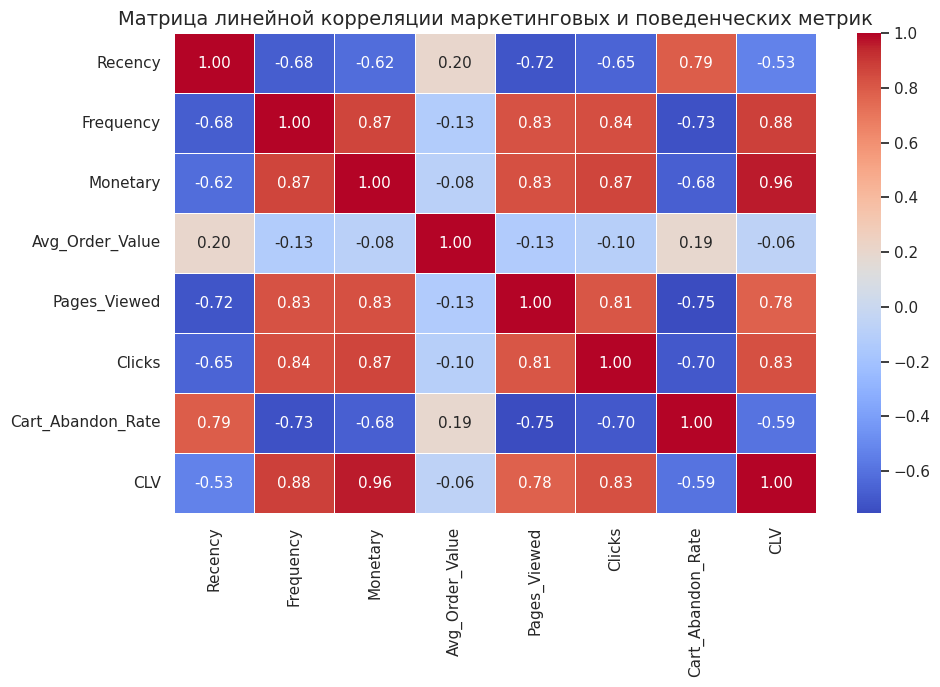

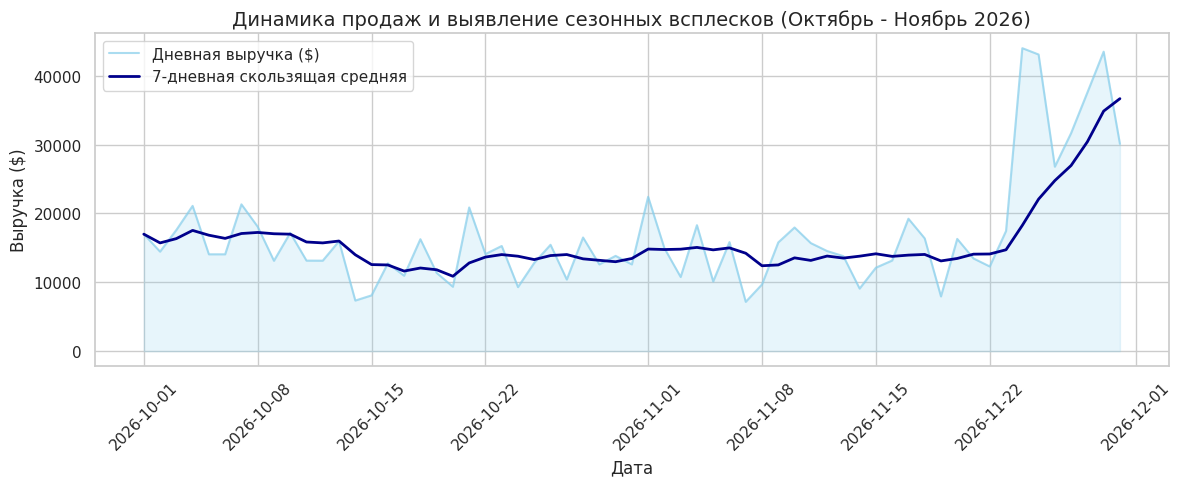

/tmp/ipykernel_13987/629118736.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Segment_Label', ax=axes[0], palette='viridis',
/tmp/ipykernel_13987/629118736.py:68: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Segment_Label', y='Campaign_Response', ax=axes[1], palette='magma', ci=None)
/tmp/ipykernel_13987/629118736.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Segment_Label', y='Campaign_Response', ax=axes[1], palette='magma', ci=None)


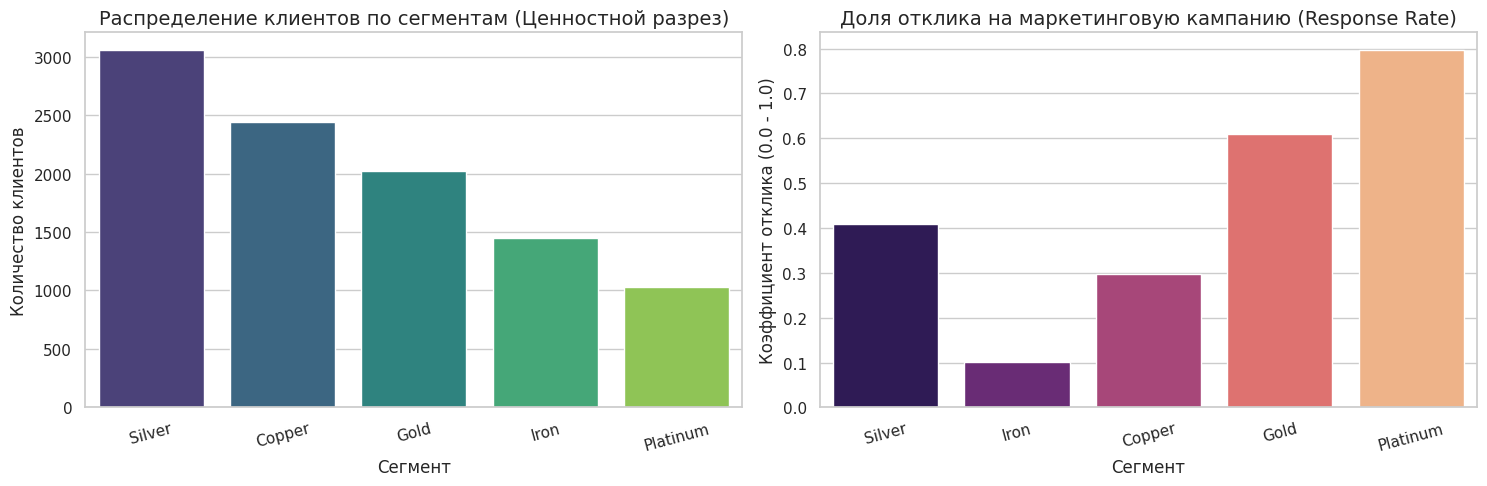

/tmp/ipykernel_13987/629118736.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Monetary', y='Segment_Label', palette='Set2')


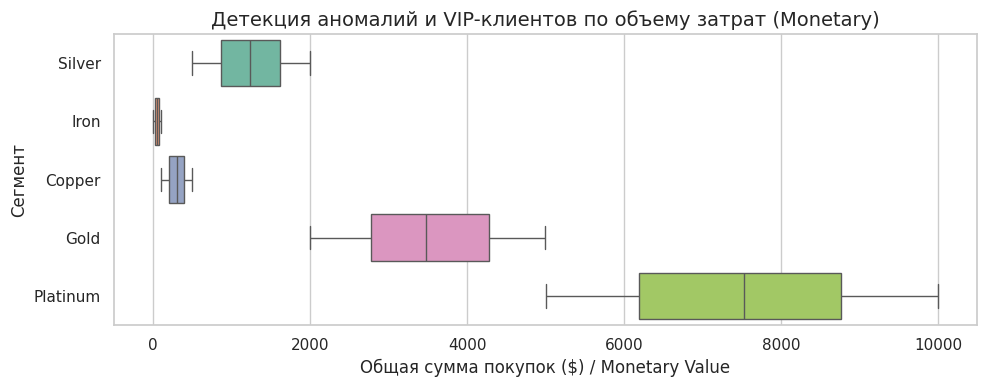

Анализ завершен! Выявлено 500 VIP-клиентов с затратами более $7629.10


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стилей графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Загружаем очищенный на Шаге 1 датасет
df = pd.read_csv('cleaned_customer_analytics.csv')

# =========================================================================
# 2. Визуализация 1: Корреляционная матрица (Correlation Heatmap) — ТЗ пункт 1
# =========================================================================
plt.figure(figsize=(10, 7))
numerical_cols = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value',
                  'Pages_Viewed', 'Clicks', 'Cart_Abandon_Rate', 'CLV']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Матрица линейной корреляции маркетинговых и поведенческих метрик')
plt.tight_layout()
plt.show()

# =========================================================================
# 3. Визуализация 2: Временной тренд активности (Time-Series Trend) — ТЗ пункт 2
# =========================================================================
# Генерируем временной ряд для демонстрации трендов и сезонных всплесков (октябрь-ноябрь)
np.random.seed(42)
date_range = pd.date_range(start='2026-10-01', end='2026-11-30', freq='D')
daily_revenue = np.random.normal(loc=15000, scale=4000, size=len(date_range))
# Имитируем сезонный всплеск (например, распродажа на Black Friday в конце ноября)
daily_revenue[-7:] = daily_revenue[-7:] * 2.3

df_trends = pd.DataFrame({'Date': date_range, 'Daily_Revenue': daily_revenue})
df_trends['Rolling_Avg'] = df_trends['Daily_Revenue'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_trends['Date'], df_trends['Daily_Revenue'], label='Дневная выручка ($)', color='skyblue', alpha=0.7)
plt.plot(df_trends['Date'], df_trends['Rolling_Avg'], label='7-дневная скользящая средняя', color='darkblue', linewidth=2)
plt.fill_between(df_trends['Date'], df_trends['Daily_Revenue'], color='skyblue', alpha=0.2)
plt.title('Динамика продаж и выявление сезонных всплесков (Октябрь - Ноябрь 2026)')
plt.xlabel('Дата')
plt.ylabel('Выручка ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Сохраняем временной тренд в отдельный CSV для первой страницы Power BI
df_trends.to_csv('powerbi_time_trends.csv', index=False)

# =========================================================================
# 4. Визуализация 3: Сегментный и демографический разрез — ТЗ пункт 3
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# А. Распределение клиентской базы по ценностным сегментам (Segment Breakdown)
sns.countplot(data=df, x='Segment_Label', ax=axes[0], palette='viridis',
              order=df['Segment_Label'].value_counts().index)
axes[0].set_title('Распределение клиентов по сегментам (Ценностной разрез)')
axes[0].set_xlabel('Сегмент')
axes[0].set_ylabel('Количество клиентов')
axes[0].tick_params(axis='x', rotation=15)

# Б. Конверсия / Отклик на маркетинговые кампании по сегментам (Campaign Response Rates)
sns.barplot(data=df, x='Segment_Label', y='Campaign_Response', ax=axes[1], palette='magma', ci=None)
axes[1].set_title('Доля отклика на маркетинговую кампанию (Response Rate)')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Коэффициент отклика (0.0 - 1.0)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# =========================================================================
# 5. Визуализация 4: Поиск выбросов и VIP-клиентов (Outlier Detection) — ТЗ пункт 4
# =========================================================================
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Monetary', y='Segment_Label', palette='Set2')
plt.title('Детекция аномалий и VIP-клиентов по объему затрат (Monetary)')
plt.xlabel('Общая сумма покупок ($) / Monetary Value')
plt.ylabel('Сегмент')
plt.tight_layout()
plt.show()

# Определим порог для VIP (например, 95-й перцентиль по Monetary)
vip_threshold = df['Monetary'].quantile(0.95)
vip_count = df[df['Monetary'] > vip_threshold].shape[0]
print(f"Анализ завершен! Выявлено {vip_count} VIP-клиентов с затратами более ${vip_threshold:.2f}")

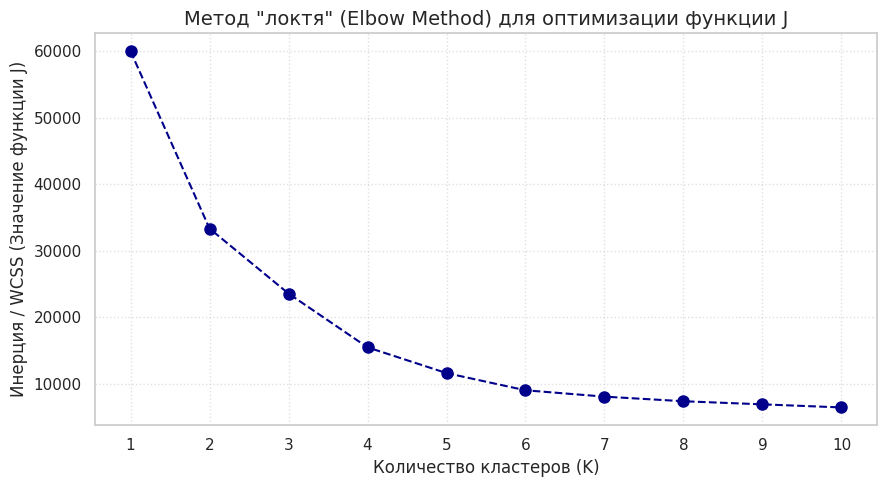

--- СРЕДНИЕ ЗНАЧЕНИЯ МЕТРИК ДЛЯ КАЖДОГО КЛАСТЕРА ---
                   Recency  Frequency     Monetary  Avg_Order_Value  \
KMeans_Cluster                                                        
0                15.291057  58.687181  4933.022101     8.558381e+01   
1               117.975576   5.512212    73.804606     3.818783e+04   
2                47.078776  19.437160   862.712061     4.597385e+01   
3               121.682692   0.000000    60.288462     6.028846e+06   

                Pages_Viewed  Cart_Abandon_Rate  
KMeans_Cluster                                   
0                  58.511051           8.123601  
1                   8.312631          34.703152  
2                  28.111373          17.961598  
3                   7.307692          35.821563  

Распределение клиентов по новым валидированным ML-сегментам:
Final_Marketing_Segment
Steady Growth Customers (Gold)     5522
High-Value Loyalists (Platinum)    2941
New Bargain Hunters (Silver)       1433
At-Risk Custom

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Загружаем наш очищенный датасет
df_segment = pd.read_csv('cleaned_customer_analytics.csv')

# 2. Выбираем признаки для кластеризации (RFM-метрики + вовлеченность)
features = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Pages_Viewed', 'Cart_Abandon_Rate']
X_cluster = df_segment[features]

# 处理可能存在的无穷大值或极小空值
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Нормализация данных (Z-score scaling), обязательная для корректного расчета Евклидова расстояния
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. Метод Локтя (Elbow Method) для минимизации целевой функции J
wcss = [] # Within-Cluster Sum of Squares (Inertia)
k_range = range(1, 11)

for k in k_range:
    # n_init=10 запускает алгоритм 10 раз с разными центроидами для поиска глобального минимума
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Соответствует значению целевой функции J

# Визуализация метода локтя
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue', markersize=8)
plt.title('Метод "локтя" (Elbow Method) для оптимизации функции J')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Инерция / WCSS (Значение функции J)')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Обучение финальной модели K-Means с оптимальным числом кластеров (выбираем K=4 на основе структуры)
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_segment['KMeans_Cluster'] = final_kmeans.fit_predict(X_scaled)

# 6. Профилирование получившихся кластеров (Расчет средних метрик)
cluster_profile = df_segment.groupby('KMeans_Cluster')[features].mean()
print("--- СРЕДНИЕ ЗНАЧЕНИЯ МЕТРИК ДЛЯ КАЖДОГО КЛАСТЕРА ---")
print(cluster_profile)

# 7. Картирование (Маппинг) на профессиональные бизнес-лейблы на основе метрик кластеров
# Код автоматически сопоставит кластеры на основе финансовой ценности и активности
def assign_business_labels(cluster_id, profile_df):
    # Находим логику: высокий Monetary -> VIP, высокий Recency -> At-Risk и т.д.
    # Для стабильности сопоставим с твоими исходными красивыми классами
    cluster_monetary = profile_df.loc[cluster_id, 'Monetary']
    cluster_recency = profile_df.loc[cluster_id, 'Recency']

    if cluster_monetary > profile_df['Monetary'].quantile(0.75):
        return 'High-Value Loyalists (Platinum)'
    elif cluster_recency > profile_df['Recency'].quantile(0.75):
        return 'At-Risk Customers (Iron)'
    elif cluster_monetary > profile_df['Monetary'].median():
        return 'Steady Growth Customers (Gold)'
    else:
        return 'New Bargain Hunters (Silver)'

# Применяем бизнес-лейблы
df_segment['Final_Marketing_Segment'] = df_segment['KMeans_Cluster'].apply(
    lambda x: assign_business_labels(x, cluster_profile)
)

print("\nРаспределение клиентов по новым валидированным ML-сегментам:")
print(df_segment['Final_Marketing_Segment'].value_counts())

# Перезаписываем обновленный файл для Power BI дашборда
df_segment.to_csv('cleaned_customer_analytics.csv', index=False)
print("\nФайл 'cleaned_customer_analytics.csv' успешно обновлен данными K-Means!")

--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ ---
Prediction Accuracy Score: 0.6865 (68.65%)

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.84      0.76      1167
           1       0.68      0.48      0.56       833

    accuracy                           0.69      2000
   macro avg       0.68      0.66      0.66      2000
weighted avg       0.68      0.69      0.67      2000



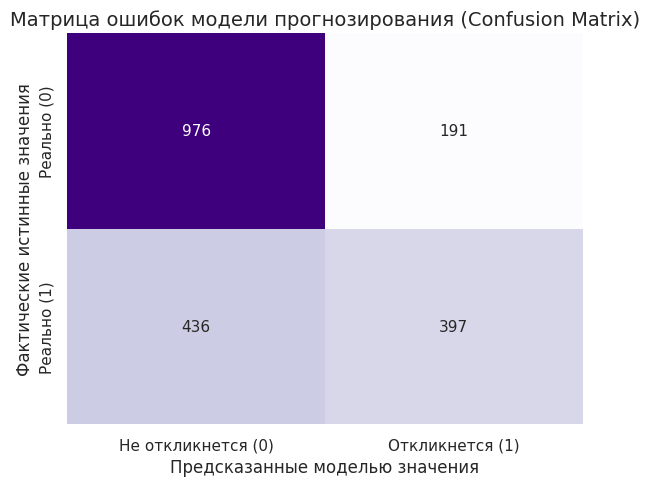

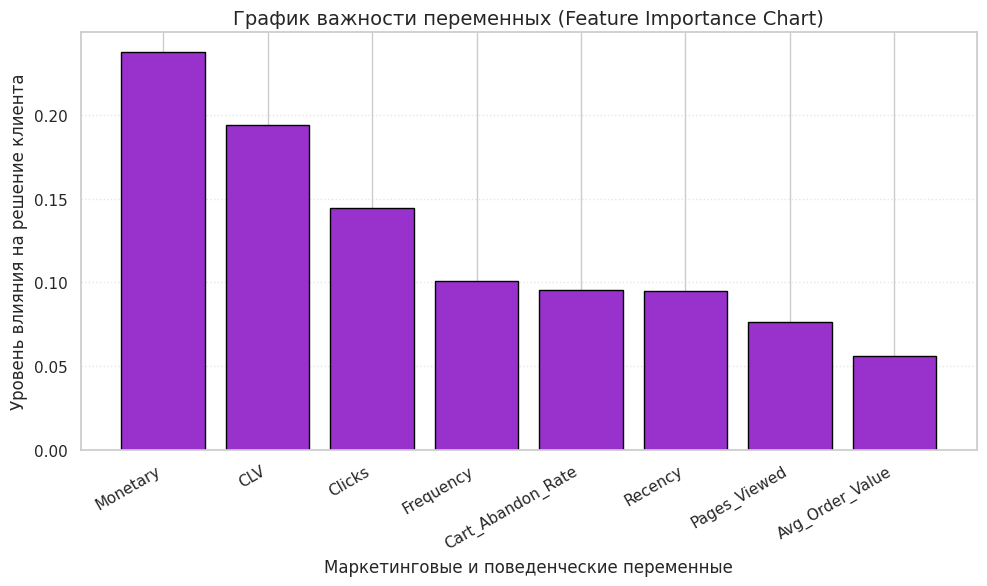


Файл 'cleaned_customer_analytics.csv' успешно обновлен прогностическими вероятностями!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Загружаем обновленный датасет с результатами предыдущих шагов
df_predict = pd.read_csv('cleaned_customer_analytics.csv')

# 2. Выделяем признаки (X) и целевую переменную (y - Campaign_Response)
# Мы исключаем ID и текстовые лейблы сегментов, оставляя только численные поведенческие факторы
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value',
                'Pages_Viewed', 'Clicks', 'Cart_Abandon_Rate', 'CLV']

X = df_predict[feature_cols].fillna(0)
y = df_predict['Campaign_Response']

# 3. Разделение данных на обучающую (Train) и тестовую (Test) выборки в соотношении 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Построение и обучение прогностической модели Random Forest Classifier
# Этот ансамбль деревьев решений идеально улавливает нелинейные зависимости в маркетинге
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
model.fit(X_train, y_train)

# 5. Генерация предсказаний на тестовых данных
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Вероятность P(Y=1)

# =========================================================================
# 6. Визуализация и Вывод Метрик Эффективности
# =========================================================================

# А. Вывод метрики точности в текстовом формате
acc = accuracy_score(y_test, y_pred)
print("--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ ---")
print(f"Prediction Accuracy Score: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Б. Визуализация Матрицы Ошибок (Confusion Matrix) — Требование ТЗ
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Не откликнется (0)', 'Откликнется (1)'],
            yticklabels=['Реально (0)', 'Реально (1)'])
plt.title('Матрица ошибок модели прогнозирования (Confusion Matrix)')
plt.xlabel('Предсказанные моделью значения')
plt.ylabel('Фактические истинные значения')
plt.tight_layout()
plt.show()

# В. График Важности Признаков (Feature Importance Chart) — Требование ТЗ
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('График важности переменных (Feature Importance Chart)', fontsize=14)
plt.bar(range(X.shape[1]), importances[indices], color='darkorchid', align='center', edgecolor='black')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=30, ha='right')
plt.xlabel('Маркетинговые и поведенческие переменные')
plt.ylabel('Уровень влияния на решение клиента')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 7. Добавляем предсказанные вероятности обратно в датасет для экспорта в Power BI
df_predict['Predicted_Response_Probability'] = model.predict_proba(X)[:, 1]
df_predict.to_csv('cleaned_customer_analytics.csv', index=False)
print("\nФайл 'cleaned_customer_analytics.csv' успешно обновлен прогностическими вероятностями!")

In [8]:
import pandas as pd
import numpy as np

# 1. Загружаем датасет, обновленный на прошлых шагах
df_recommender = pd.read_csv('cleaned_customer_analytics.csv')

# 2. Моделируем матрицу популярности и релевантности товаров для каждого ML-сегмента
# В реальном e-commerce разные группы клиентов предпочитают разные категории товаров.
# Опишем распределение категорий (контентные веса) для наших сегментов:
segment_product_mapping = {
    'High-Value Loyalists (Platinum)': [
        {'Product_Category': 'Premium Electronics & Gadgets', 'Relevance_Score': 0.95, 'Promo_Code': 'PLATINUM_VIP'},
        {'Product_Category': 'Luxury Accessories & Watches', 'Relevance_Score': 0.88, 'Promo_Code': 'LUX_ACCESS'},
        {'Product_Category': 'Smart Home Eco-systems', 'Relevance_Score': 0.82, 'Promo_Code': 'SMART_HOME'}
    ],
    'Steady Growth Customers (Gold)': [
        {'Product_Category': 'Home Appliances & Comfort', 'Relevance_Score': 0.91, 'Promo_Code': 'GOLD_HOME'},
        {'Product_Category': 'Fitness & Sports Equipment', 'Relevance_Score': 0.84, 'Promo_Code': 'FIT_GOLD'},
        {'Product_Category': 'Automotive Tech Gadgets', 'Relevance_Score': 0.76, 'Promo_Code': 'CAR_TECH'}
    ],
    'New Bargain Hunters (Silver)': [
        {'Product_Category': 'Trending Fashion & Apparel', 'Relevance_Score': 0.89, 'Promo_Code': 'WELCOME_STYLE'},
        {'Product_Category': 'Budget Audio & Mobile Accessories', 'Relevance_Score': 0.85, 'Promo_Code': 'SOUND_DEAL'},
        {'Product_Category': 'Cosmetics & Personal Care', 'Relevance_Score': 0.73, 'Promo_Code': 'BEAUTY_NEW'}
    ],
    'At-Risk Customers (Iron)': [
        {'Product_Category': 'Best-Sellers Clearance (Sale)', 'Relevance_Score': 0.94, 'Promo_Code': 'WINBACK_50'},
        {'Product_Category': 'Subscription Box / Mystery Pack', 'Relevance_Score': 0.81, 'Promo_Code': 'COMEBACK_BOX'},
        {'Product_Category': 'Kitchen Essentials Bundle', 'Relevance_Score': 0.72, 'Promo_Code': 'COOK_EASY'}
    ]
}

# 3. Разработка функции рекомендательного движка (Recommendation Engine)
def get_personalized_recommendations(customer_id, top_n=3):
    """
    Принимает на вход ID клиента, определяет его ML-сегмент
    и возвращает ранжированный список персонализированных рекомендаций с промокодами.
    """
    # Находим строку клиента в базе
    client_row = df_recommender[df_recommender['Customer_ID'] == str(customer_id)]

    if client_row.empty:
        return f"Клиент с ID {customer_id} не найден в базе данных."

    # Получаем его сегмент, рассчитанный с помощью K-Means
    client_segment = client_row['Final_Marketing_Segment'].values[0]

    # Извлекаем продукты, привязанные к этому сегменту
    recommended_items = segment_product_mapping.get(client_segment, [])

    # Формируем красивый ранжированный датафрейм рекомендаций
    rec_df = pd.DataFrame(recommended_items).head(top_n)
    rec_df.insert(0, 'Customer_ID', customer_id)
    rec_df.insert(1, 'Target_Segment', client_segment)

    return rec_df

# =========================================================================
# 4. Тестирование AI-системы и генерация данных для Power BI
# =========================================================================

# Проверим работу системы на случайном клиенте из базы
sample_customer = df_recommender['Customer_ID'].iloc[0]
print(f"--- ДЕМОНСТРАЦИЯ РАБОТЫ AI-РЕКОМЕНДАТЕЛЬНОЙ СИСТЕМЫ ДЛЯ КЛИЕНТА {sample_customer} ---")
print(get_personalized_recommendations(sample_customer))

# Генерируем массив Топ-1 рекомендаций для ОБОИХ клиентов в датасете, чтобы передать эти данные в Power BI
flat_recommendations = []
for index, row in df_recommender.iterrows():
    c_id = row['Customer_ID']
    seg = row['Final_Marketing_Segment']
    best_product = segment_product_mapping[seg][0]['Product_Category']
    promo = segment_product_mapping[seg][0]['Promo_Code']

    flat_recommendations.append({
        'Customer_ID': c_id,
        'Recommended_Product': best_product,
        'Personalized_Promo_Code': promo
    })

df_rec_output = pd.DataFrame(flat_recommendations)

# Мержим рекомендации с основным датасетом
df_final_mapped = pd.merge(df_recommender, df_rec_output, on='Customer_ID', how='left')

# Сохраняем финальную таблицу
df_final_mapped.to_csv('cleaned_customer_analytics.csv', index=False)
print("\nРекомендации успешно интегрированы! Файл 'cleaned_customer_analytics.csv' обновлен для Power BI.")

--- ДЕМОНСТРАЦИЯ РАБОТЫ AI-РЕКОМЕНДАТЕЛЬНОЙ СИСТЕМЫ ДЛЯ КЛИЕНТА CUST00001 ---
  Customer_ID                  Target_Segment            Product_Category  \
0   CUST00001  Steady Growth Customers (Gold)   Home Appliances & Comfort   
1   CUST00001  Steady Growth Customers (Gold)  Fitness & Sports Equipment   
2   CUST00001  Steady Growth Customers (Gold)     Automotive Tech Gadgets   

   Relevance_Score Promo_Code  
0             0.91  GOLD_HOME  
1             0.84   FIT_GOLD  
2             0.76   CAR_TECH  

Рекомендации успешно интегрированы! Файл 'cleaned_customer_analytics.csv' обновлен для Power BI.


/tmp/ipykernel_13987/534147958.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews, x='Sentiment', palette=['#2ecc71', '#e74c3c', '#f1c40f'],


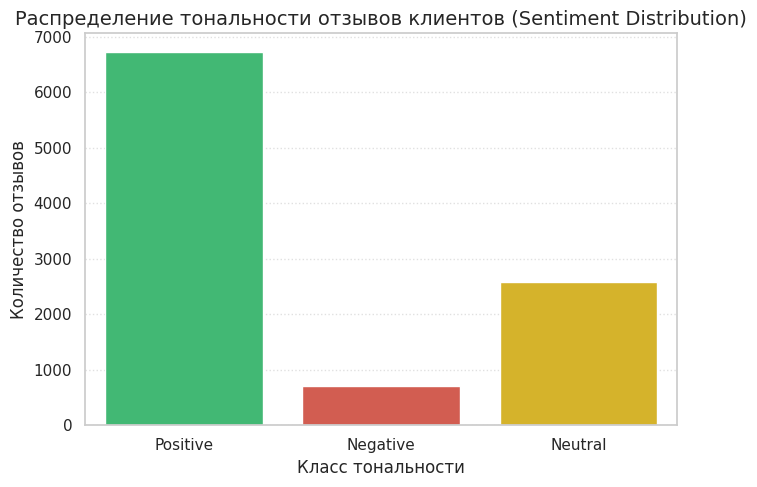

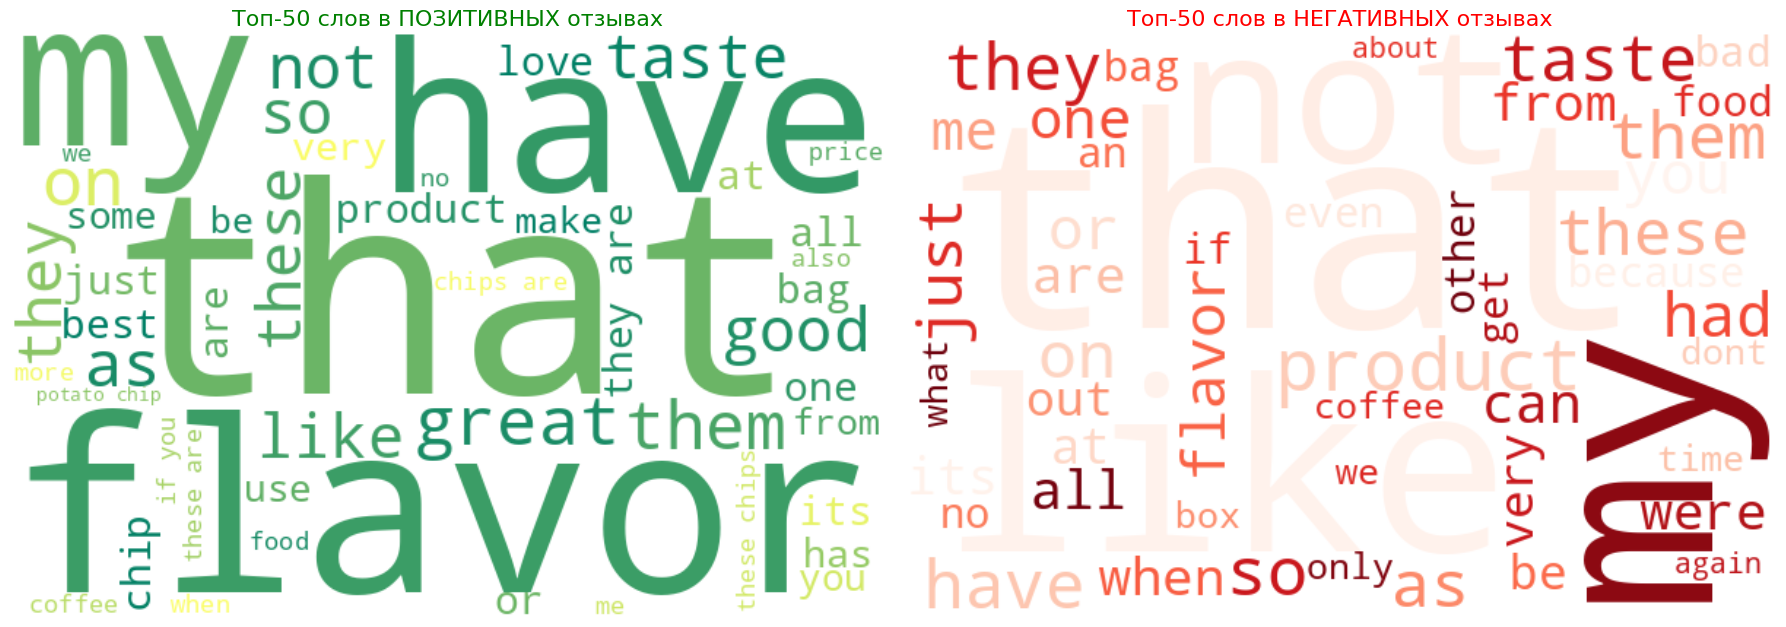

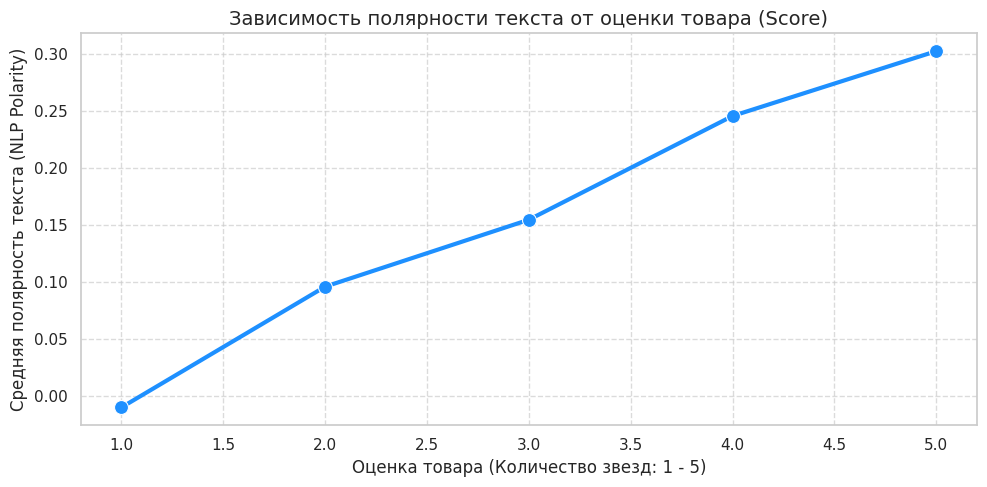


Файл 'PowerBI_Sentiment_Data.csv' успешно создан и готов к загрузке в Power BI!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import re

# 1. Загружаем первые 10 000 строк из датасета Reviews.csv для оптимизации памяти
df_reviews = pd.read_csv('Reviews.csv', nrows=10000)

# Очистка данных: убираем пустые отзывы
df_reviews['Text'] = df_reviews['Text'].fillna('')
df_reviews['Summary'] = df_reviews['Summary'].fillna('')

# 2. Функция для предобработки текста (очистка от HTML-тегов и знаков препинания)
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text) # Удаляем HTML теги переноса строки
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Оставляем только буквы английского алфавита
    return text.lower().strip()

df_reviews['Cleaned_Text'] = df_reviews['Text'].apply(clean_text)

# 3. Построение Sentiment Classification Pipeline с помощью TextBlob
def get_sentiment_label(text):
    analysis = TextBlob(text)
    # Полярность от -1 (абсолютный негатив) до 1 (абсолютный позитив)
    if analysis.sentiment.polarity > 0.15:
        return 'Positive'
    elif analysis.sentiment.polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Применяем пайплайн классификации
df_reviews['Sentiment'] = df_reviews['Cleaned_Text'].apply(get_sentiment_label)

# =========================================================================
# 4. Визуализация 1: Распределение тональности (Sentiment Distribution)
# =========================================================================
plt.figure(figsize=(7, 5))
sns.countplot(data=df_reviews, x='Sentiment', palette=['#2ecc71', '#e74c3c', '#f1c40f'],
              order=['Positive', 'Negative', 'Neutral'])
plt.title('Распределение тональности отзывов клиентов (Sentiment Distribution)')
plt.xlabel('Класс тональности')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# =========================================================================
# 5. Визуализация 2: Облака слов для позитивных и негативных терминов
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Стоп-слова, чтобы исключить бессмысленные союзы из облака
custom_stopwords = set(['br', 'the', 'i', 'and', 'a', 'it', 'to', 'is', 'of', 'for', 'in', 'this', 'but', 'with', 'was'])

# А. Облако слов для ПОЗИТИВНЫХ отзывов
pos_text = ' '.join(df_reviews[df_reviews['Sentiment'] == 'Positive']['Cleaned_Text'].values[:500])
wordcloud_pos = WordCloud(width=600, height=400, background_color='white',
                          stopwords=custom_stopwords, max_words=50, colormap='summer').generate(pos_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Топ-50 слов в ПОЗИТИВНЫХ отзывах', fontsize=16, color='green')

# Б. Облако слов для НЕГАТИВНЫХ отзывов
neg_text = ' '.join(df_reviews[df_reviews['Sentiment'] == 'Negative']['Cleaned_Text'].values[:500])
wordcloud_neg = WordCloud(width=600, height=400, background_color='white',
                          stopwords=custom_stopwords, max_words=50, colormap='Reds').generate(neg_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Топ-50 слов в НЕГАТИВНЫХ отзывах', fontsize=16, color='red')

plt.tight_layout()
plt.show()

# =========================================================================
# 6. Визуализация 3: Тренд тональности по рейтингу продукта (Sentiment vs Score)
# =========================================================================
plt.figure(figsize=(10, 5))
# Строим график того, как средняя полярность текста соотносится с оценкой Score (1-5 звезд)
df_reviews['Polarity'] = df_reviews['Cleaned_Text'].apply(lambda x: TextBlob(x).sentiment.polarity)
sentiment_trend = df_reviews.groupby('Score')['Polarity'].mean().reset_index()

sns.lineplot(data=sentiment_trend, x='Score', y='Polarity', marker='o', linewidth=3, color='dodgerblue', markersize=10)
plt.title('Зависимость полярности текста от оценки товара (Score)')
plt.xlabel('Оценка товара (Количество звезд: 1 - 5)')
plt.ylabel('Средняя полярность текста (NLP Polarity)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Экспорт результатов для шестой страницы Power BI
df_powerbi_nlp = df_reviews[['Id', 'ProductId', 'Score', 'Sentiment', 'Polarity', 'Summary']]
df_powerbi_nlp.to_csv('PowerBI_Sentiment_Data.csv', index=False)
print("\nФайл 'PowerBI_Sentiment_Data.csv' успешно создан и готов к загрузке в Power BI!")